# AML s26 - Autoencoder 

Note we need to install the following to work with PyTorch and images:
> conda install torchvision

### Load libraries, ... 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = (
    torch.device("mps")  if torch.backends.mps.is_available() else
    torch.device("cuda") if torch.cuda.is_available()         else
    torch.device("xpu") if torch.xpu.is_available()         else
    torch.device("cpu")
)

print(f'Using device: {device}')

Using device: xpu


### Load MNIST Data

Size: ~68 MB in './data'

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples:     {len(test_dataset)}')
print(f'Input dimensions: 28x28 = {28*28} pixels')

100%|██████████| 9.91M/9.91M [00:01<00:00, 9.62MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.02MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 7.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.77MB/s]

Training samples: 60000
Test samples:     10000
Input dimensions: 28x28 = 784 pixels


###  Visualize the data

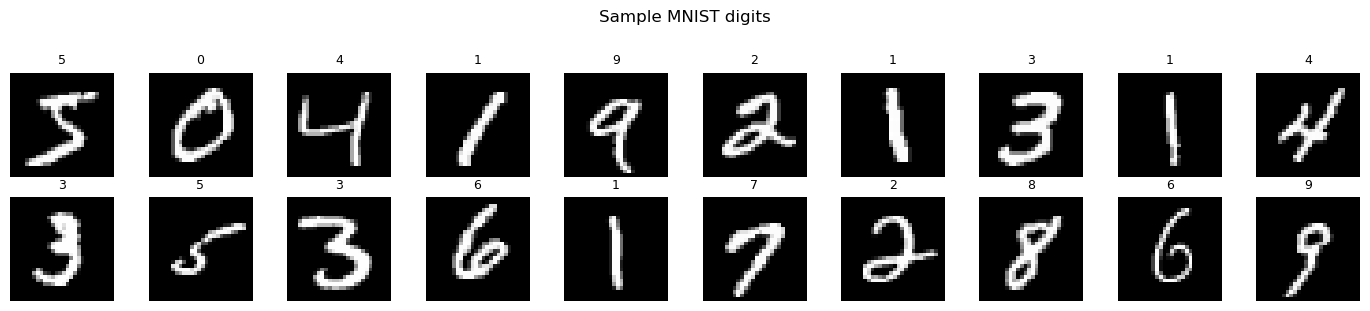

In [3]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(20):
    img, label = train_dataset[i]
    axes[i // 10, i % 10].imshow(img.squeeze(), cmap='gray')
    axes[i // 10, i % 10].set_title(str(label), fontsize=9)
    axes[i // 10, i % 10].axis('off')
plt.suptitle('Sample MNIST digits', y=1.02)
plt.tight_layout()
plt.show()

### Define the Autoencoder

Architecture:
```
Input (784)
Encoder: 784 → 256 → 128 → latent_dim
Decoder:                   latent_dim → 128 → 256 → 784
```

Note `LATENT_DIM` affects reconstruction quality!

In [4]:
LATENT_DIM = 16  # try 2, 8, 32, 64

class Autoencoder(nn.Module):
    def __init__(self, latent_dim: int = 16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256),        nn.ReLU(),
            nn.Linear(256, 784),        nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

model = Autoencoder(latent_dim=LATENT_DIM).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')
print(f'Compression ratio: {784 / LATENT_DIM:.1f}x  (784 → {LATENT_DIM})')

Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

Total parameters: 472,608
Compression ratio: 49.0x  (784 → 16)


### Train the Autoencoder

In [5]:
EPOCHS = 10
LR     = 1e-3

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses, test_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # --- train ---
    model.train()
    running = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        recon, _ = model(imgs)
        loss = criterion(recon, imgs.view(imgs.size(0), -1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item()
    train_losses.append(running / len(train_loader))

    # --- evaluate ---
    model.eval()
    with torch.no_grad():
        val = sum(
            criterion(model(imgs.to(device))[0], imgs.to(device).view(imgs.size(0), -1)).item()
            for imgs, _ in test_loader
        ) / len(test_loader)
    test_losses.append(val)

    print(f'Epoch {epoch:2d}/{EPOCHS}  train loss: {train_losses[-1]:.5f}  test loss: {test_losses[-1]:.5f}')

print('\nTraining complete!')

Epoch  1/10  train loss: 0.06457  test loss: 0.03893
Epoch  2/10  train loss: 0.03237  test loss: 0.02728
Epoch  3/10  train loss: 0.02530  test loss: 0.02258
Epoch  4/10  train loss: 0.02155  test loss: 0.01984
Epoch  5/10  train loss: 0.01945  test loss: 0.01809
Epoch  6/10  train loss: 0.01788  test loss: 0.01684
Epoch  7/10  train loss: 0.01657  test loss: 0.01566
Epoch  8/10  train loss: 0.01545  test loss: 0.01461
Epoch  9/10  train loss: 0.01462  test loss: 0.01405
Epoch 10/10  train loss: 0.01402  test loss: 0.01357

Training complete!


### Plot Training Loss

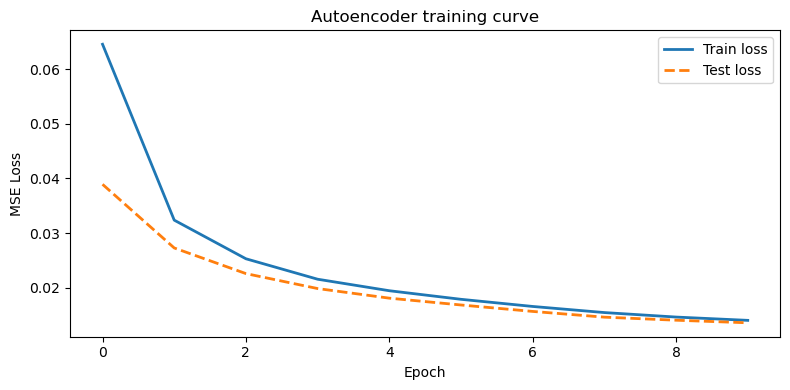

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss', linewidth=2)
plt.plot(test_losses,  label='Test loss',  linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder training curve')
plt.legend()
plt.tight_layout()
plt.show()

### Visualize Reconstructions

Top row: original images. Bottom row: reconstructions.

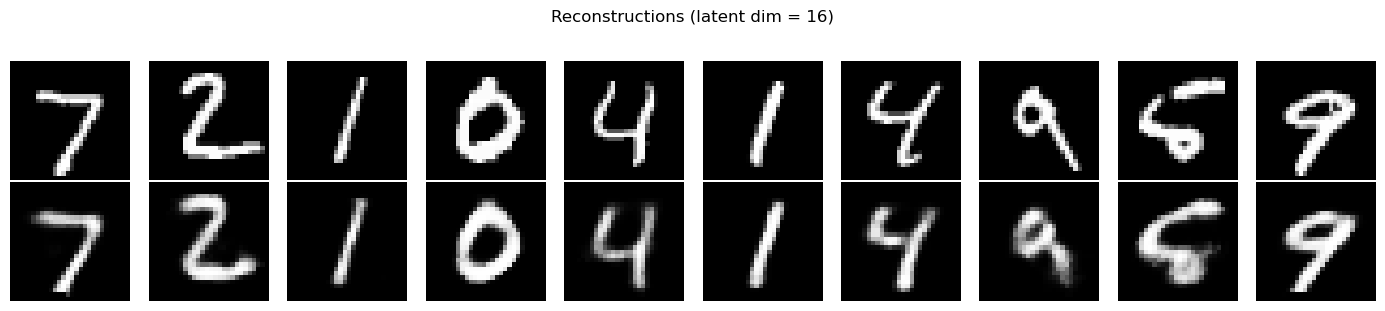

In [7]:
model.eval()
with torch.no_grad():
    sample_imgs, _ = next(iter(test_loader))
    sample_imgs = sample_imgs[:10].to(device)
    recon_imgs, latent_vecs = model(sample_imgs)
    recon_imgs = recon_imgs.view(-1, 28, 28).cpu().numpy()
    sample_imgs = sample_imgs.squeeze().cpu().numpy()

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(10):
    axes[0, i].imshow(sample_imgs[i], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_imgs[i], cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Reconstructed', fontsize=10)
plt.suptitle(f'Reconstructions (latent dim = {LATENT_DIM})', y=1.02)
plt.tight_layout()
plt.show()

### Visualize the Latent Space (2D)

Re-use the current encoder and project with PCA to plot where digits cluster in latent space.

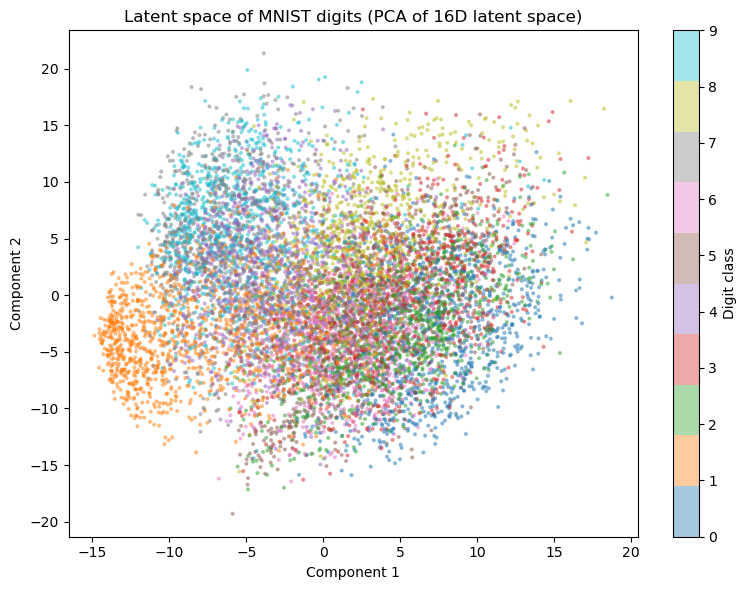

In [8]:
from sklearn.decomposition import PCA

# Encode the entire test set
all_z, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        _, z = model(imgs.to(device))
        all_z.append(z.cpu().numpy())
        all_labels.append(labels.numpy())

all_z      = np.concatenate(all_z)
all_labels = np.concatenate(all_labels)

# Project to 2D if latent_dim > 2
if LATENT_DIM > 2:
    z_2d = PCA(n_components=2).fit_transform(all_z)
    title_suffix = f'(PCA of {LATENT_DIM}D latent space)'
else:
    z_2d = all_z
    title_suffix = '(2D latent space)'

plt.figure(figsize=(8, 6))
scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=all_labels, cmap='tab10', alpha=0.4, s=4)
plt.colorbar(scatter, ticks=range(10), label='Digit class')
plt.title(f'Latent space of MNIST digits {title_suffix}')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.tight_layout()
plt.show()

### Denoising Experiment

Add Gaussian noise to test images and see how well the autoencoder cleans them up (it was trained on clean images, so this tests generalization).

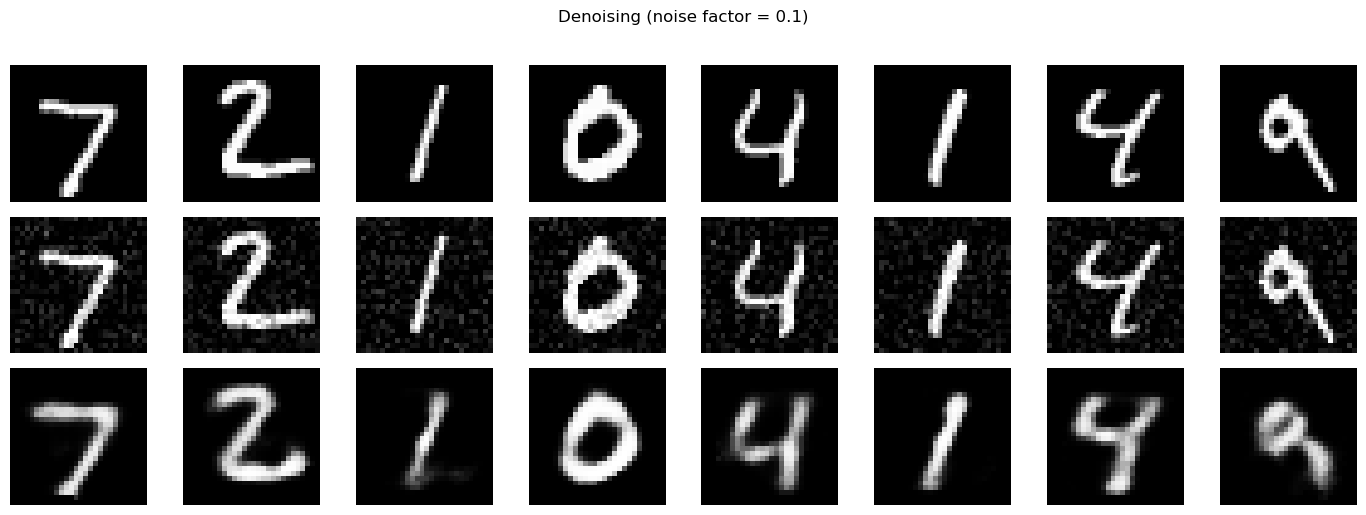

In [9]:
NOISE_FACTOR = 0.1

model.eval()
with torch.no_grad():
    clean, _ = next(iter(test_loader))
    clean = clean[:8].to(device)
    noisy = torch.clamp(clean + NOISE_FACTOR * torch.randn_like(clean), 0, 1)
    recon, _ = model(noisy)
    recon = recon.view(-1, 28, 28).cpu().numpy()

fig, axes = plt.subplots(3, 8, figsize=(14, 5))
labels = ['Clean', 'Noisy', 'Denoised']
imgs_list = [clean.squeeze().cpu().numpy(),
             noisy.squeeze().cpu().numpy(),
             recon]

for row, (row_imgs, lbl) in enumerate(zip(imgs_list, labels)):
    for col in range(8):
        axes[row, col].imshow(row_imgs[col], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(lbl, fontsize=10)

plt.suptitle(f'Denoising (noise factor = {NOISE_FACTOR})', y=1.02)
plt.tight_layout()
plt.show()